In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df  = pd.read_csv("commodity_prices.csv")
df

,Unnamed: 0,date,oil_brent,oil_dubai,coffee_arabica,coffee_robustas,tea_columbo,tea_kolkata,tea_mombasa,sugar_eu,sugar_us,sugar_world
0,1,1960-01-01,1.63,1.63,0.940900,0.696864,0.930301,1.121401,1.037400,0.122356,0.116845,0.066600
1,2,1960-02-01,1.63,1.63,0.946900,0.688707,0.930301,1.121401,1.037400,0.122356,0.119049,0.067900
2,3,1960-03-01,1.63,1.63,0.928100,0.688707,0.930301,1.121401,1.037400,0.122356,0.121254,0.068300
3,4,1960-04-01,1.63,1.63,0.930300,0.684519,0.930301,1.121401,1.037400,0.122356,0.123459,0.068100
4,5,1960-05-01,1.63,1.63,0.920000,0.690692,0.930301,1.121401,1.037400,0.122356,0.121254,0.068300
...,...,...,...,...,...,...,...,...,...,...,...,...
751,752,2022-08-01,98.60,97.75,5.917861,2.417366,4.210000,3.538154,2.360000,0.330773,0.782199,0.393525
752,753,2022-09-01,90.16,90.63,5.897138,2.455065,4.490000,3.153198,2.360000,0.323621,0.770956,0.390659
753,754,2022-10-01,93.13,90.59,5.292852,2.270979,4.135621,2.833112,2.457500,0.320943,0.762578,0.386911
754,755,2022-11-01,91.07,86.28,4.715462,2.041258,3.831528,2.849979,2.490000,0.332993,0.792340,0.407414


In [3]:
df.shape

(756, 12)

In [5]:
df.drop(columns = 'Unnamed: 0',inplace = True)

In [6]:
df

,date,oil_brent,oil_dubai,coffee_arabica,coffee_robustas,tea_columbo,tea_kolkata,tea_mombasa,sugar_eu,sugar_us,sugar_world
0,1960-01-01,1.63,1.63,0.940900,0.696864,0.930301,1.121401,1.037400,0.122356,0.116845,0.066600
1,1960-02-01,1.63,1.63,0.946900,0.688707,0.930301,1.121401,1.037400,0.122356,0.119049,0.067900
2,1960-03-01,1.63,1.63,0.928100,0.688707,0.930301,1.121401,1.037400,0.122356,0.121254,0.068300
3,1960-04-01,1.63,1.63,0.930300,0.684519,0.930301,1.121401,1.037400,0.122356,0.123459,0.068100
4,1960-05-01,1.63,1.63,0.920000,0.690692,0.930301,1.121401,1.037400,0.122356,0.121254,0.068300
...,...,...,...,...,...,...,...,...,...,...,...
751,2022-08-01,98.60,97.75,5.917861,2.417366,4.210000,3.538154,2.360000,0.330773,0.782199,0.393525
752,2022-09-01,90.16,90.63,5.897138,2.455065,4.490000,3.153198,2.360000,0.323621,0.770956,0.390659
753,2022-10-01,93.13,90.59,5.292852,2.270979,4.135621,2.833112,2.457500,0.320943,0.762578,0.386911
754,2022-11-01,91.07,86.28,4.715462,2.041258,3.831528,2.849979,2.490000,0.332993,0.792340,0.407414


In [7]:
#check for nulls
df.isnull().sum()

date               0
oil_brent          0
oil_dubai          0
coffee_arabica     0
coffee_robustas    0
tea_columbo        0
tea_kolkata        0
tea_mombasa        0
sugar_eu           0
sugar_us           0
sugar_world        0
dtype: int64

In [8]:
#check for duplicates
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

date                object
oil_brent          float64
oil_dubai          float64
coffee_arabica     float64
coffee_robustas    float64
tea_columbo        float64
tea_kolkata        float64
tea_mombasa        float64
sugar_eu           float64
sugar_us           float64
sugar_world        float64
dtype: object

In [10]:
#convert date column to datetime from object
df['date'] = pd.to_datetime(df["date"], format="%Y-%m-%d", errors = "coerce")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             756 non-null    datetime64[ns]
 1   oil_brent        756 non-null    float64       
 2   oil_dubai        756 non-null    float64       
 3   coffee_arabica   756 non-null    float64       
 4   coffee_robustas  756 non-null    float64       
 5   tea_columbo      756 non-null    float64       
 6   tea_kolkata      756 non-null    float64       
 7   tea_mombasa      756 non-null    float64       
 8   sugar_eu         756 non-null    float64       
 9   sugar_us         756 non-null    float64       
 10  sugar_world      756 non-null    float64       
dtypes: datetime64[ns](1), float64(10)
memory usage: 65.1 KB


In [12]:
#What is the maximum price of coffee robustas and in which year
df['coffee_robustas'].max()

6.883547

In [14]:
df[df['coffee_robustas']==df['coffee_robustas'].max()]['date'].dt.year

207    1977
Name: date, dtype: int32

In [16]:
#75th percentile of sugar price in EU
per_75 = df['sugar_eu'].quantile(0.75)
print("75th percentile of sugar EU:",per_75)

75th percentile of sugar EU: 0.56951937998


In [18]:
np.percentile(df['sugar_eu'],75)

np.float64(0.56951937998)

In [19]:
#Find the skewness of price distribution of arabica, plot the histogram
arabica_skew = df['coffee_arabica'].skew()
print(f"Skewness of Arabica coffee price distribution: {arabica_skew}")


Skewness of Arabica coffee price distribution: 0.5903976942861767


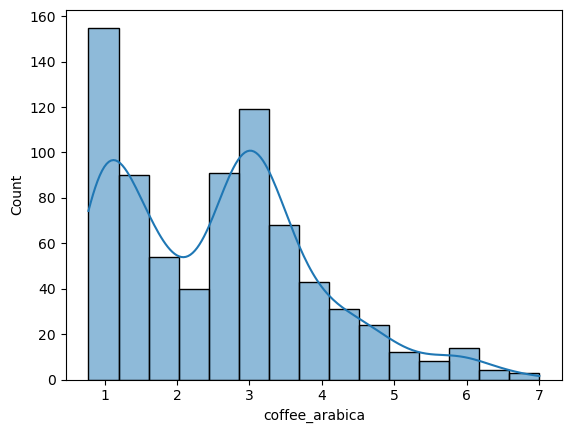

In [21]:
sns.histplot(df['coffee_arabica'],kde = True)
plt.show()

In [22]:
df['coffee_arabica'].mean()

np.float64(2.576554794940582)

In [23]:
df['coffee_arabica'].median()

2.6977944369999998

In [25]:
#Is the sugar distribution in US different from normal distribution
from scipy import stats
test,p_val = stats.normaltest(df['sugar_us'])

if p_val>0.05:
  print("failed to reject the null hypothesis")
else:
  print("Reject the null hypothesis")

failed to reject the null hypothesis


In [26]:
p_val

np.float64(0.39009821516930415)

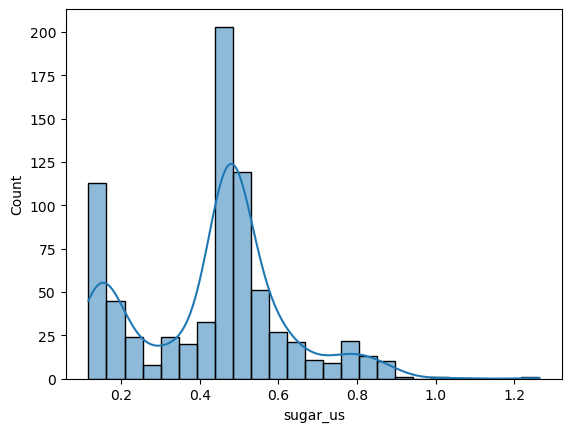

In [29]:
sns.histplot(df['sugar_us'],kde=True)
plt.show()

In [30]:
df['sugar_us'].skew()

np.float64(0.10340297222720043)

In [31]:
# How many times does the price of Dubai oil exceed the price of Brent oil by a certain threshold 0.5
answer = df[df['oil_dubai'] > df['oil_brent']+0.5]
answer

,date,oil_brent,oil_dubai,coffee_arabica,coffee_robustas,tea_columbo,tea_kolkata,tea_mombasa,sugar_eu,sugar_us,sugar_world
232,1979-05-01,32.750000,34.250000,3.302300,3.255800,0.522197,2.186726,1.603823,0.367731,0.315922,0.173100
466,1998-11-01,10.920000,11.760000,2.565500,1.767200,1.876100,1.928400,1.588000,0.607600,0.481300,0.177700
593,2009-06-01,68.616818,69.210909,3.302300,1.626789,3.136443,2.800668,2.407500,0.553510,0.491530,0.362219
598,2009-11-01,77.036667,77.625238,3.355652,1.531770,3.349507,2.912281,2.906000,0.496348,0.702458,0.490748
599,2009-12-01,74.669545,75.488636,3.486816,1.540721,3.267095,2.676978,2.976667,0.489241,0.734209,0.518747
604,2010-05-01,76.250952,76.874000,3.820166,1.556682,3.218563,2.847987,2.330000,0.420977,0.681062,0.335102
722,2020-03-01,32.980000,33.750000,3.270113,1.487237,3.080000,1.327757,1.994000,0.361306,0.597232,0.260807
724,2020-05-01,31.020000,31.560000,3.303403,1.422641,3.760000,1.789110,1.972500,0.356016,0.569894,0.241626


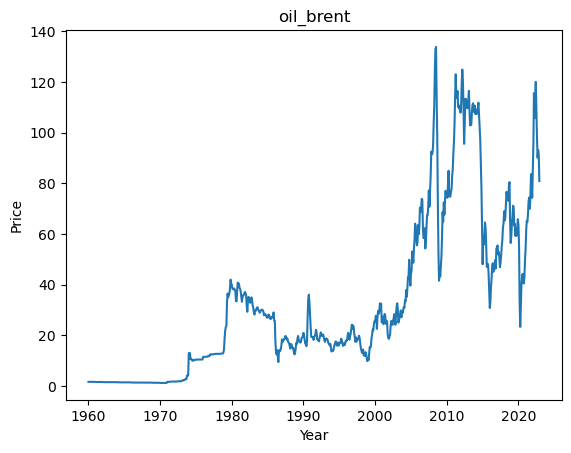

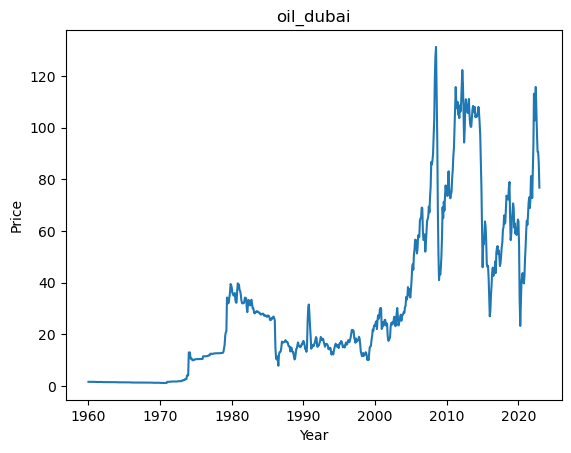

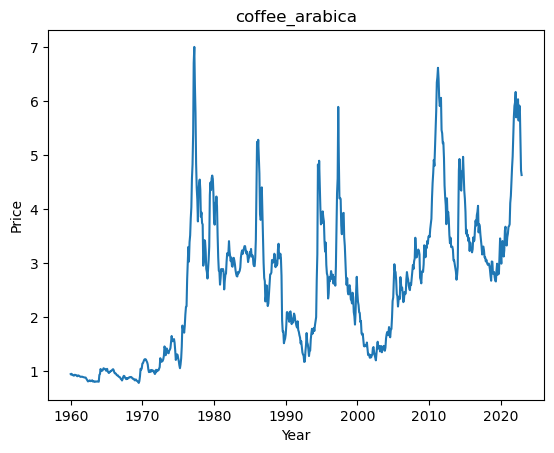

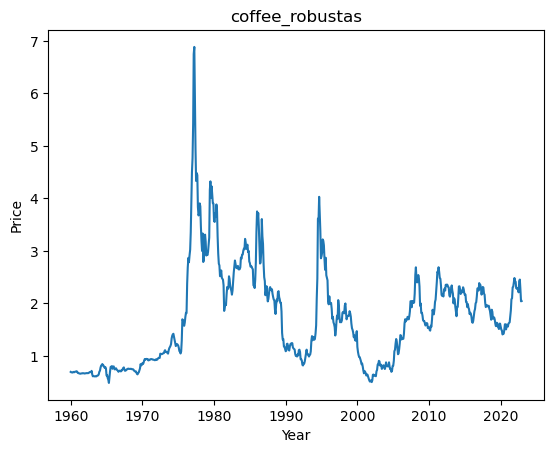

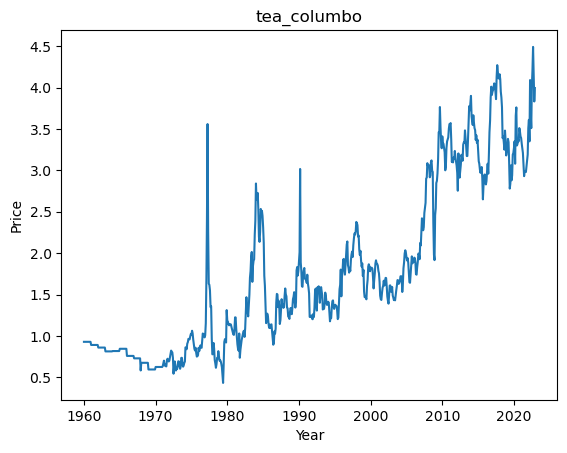

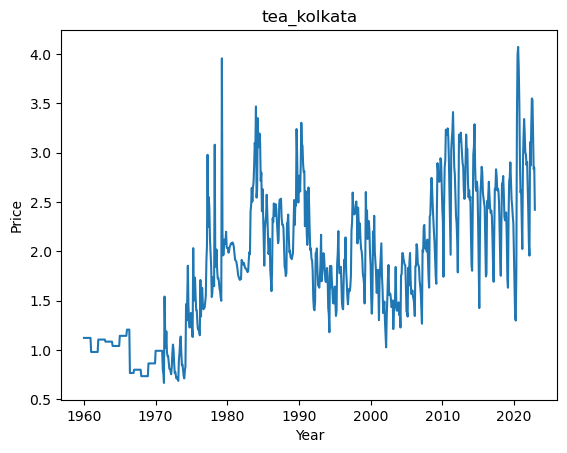

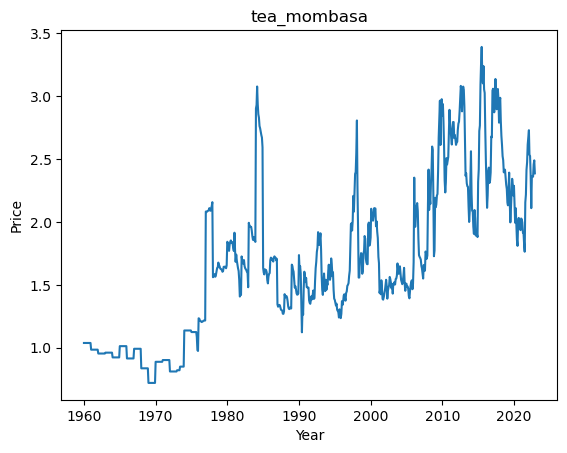

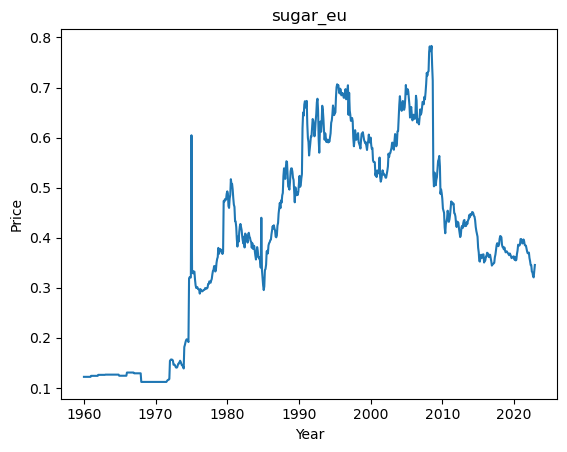

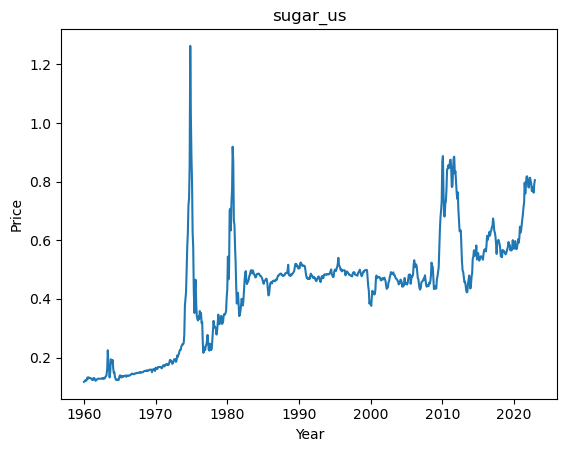

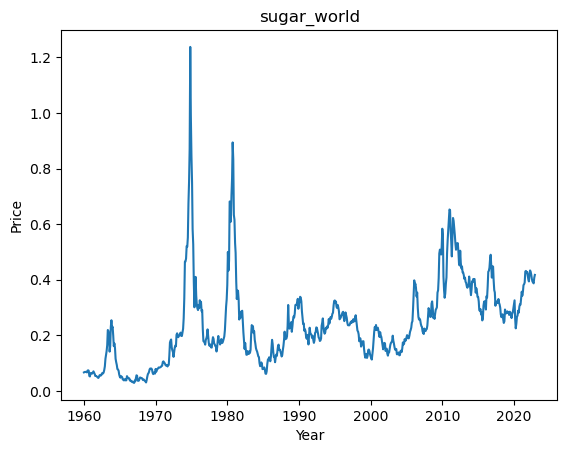

In [33]:
#what is the overall price trend for each commodity
commodities = [
    "oil_brent", "oil_dubai",
    "coffee_arabica", "coffee_robustas",
    "tea_columbo", "tea_kolkata", "tea_mombasa",
    "sugar_eu", "sugar_us", "sugar_world"
]
for commodity in commodities:
    plt.plot(df["date"], df[commodity], label=commodity)
    plt.xlabel("Year")
    plt.ylabel("Price")
    plt.title(commodity)
    plt.show()